# <center> VAI Store - Engenharia de Variáveis </center>

---

Com base nos **_insights_** da Análise Exploratória de Dados, nosso objetivo nesta etapa é **traduzir os padrões que descobrimos** (como sazonalidade e diferença entre filiais) em _**features**_ que o modelo possa usar para prever a demanda dos produtos.

### **1. Configuração e Imports**

Visão Geral: Esta etapa importa as bibliotecas necessárias (pandas, numpy, os, holidays) e define os caminhos relativos para os arquivos de dados. O arquivo de saída é nomeado feature_engineered_dataset_SKU.parquet para refletir a nova granularidade de agregação (por SKU).

In [103]:
import pandas as pd
import numpy as np
import os
import holidays

# Define os caminhos relativos (subindo um nível)
RAW_DATA_PATH = os.path.join('..', 'data', 'raw')
VENDAS_FILE = os.path.join(RAW_DATA_PATH, 'vendas.csv')
PRODUTO_FILE = os.path.join(RAW_DATA_PATH, 'produto.csv')

PROCESSED_DATA_PATH = os.path.join('..', 'data', 'processed')
# Novo arquivo de saída focado no SKU
OUTPUT_FILE = os.path.join(PROCESSED_DATA_PATH, 'feature_engineered_dataset_SKU.parquet')

os.makedirs(PROCESSED_DATA_PATH, exist_ok=True)

print(f"Lendo dados de: {os.path.abspath(RAW_DATA_PATH)}")
print(f"Salvando dados em: {os.path.abspath(PROCESSED_DATA_PATH)}")

Lendo dados de: c:\Users\felip\OneDrive\Documentos\GitHub\Grupo6-ProjetoFinal\data\raw
Salvando dados em: c:\Users\felip\OneDrive\Documentos\GitHub\Grupo6-ProjetoFinal\data\processed


### **2. Funções Auxiliares de Carga e Limpeza**

Visão Geral: Para manter o notebook limpo, definiremos duas funções auxiliares. A load_csv lida com os diferentes tipos de codificação (utf-8 ou latin1) que podemos encontrar. A clean_sku padroniza a coluna SKU, que observamos ter espaços extras e tipo de dado incorreto, garantindo que as chaves de merge sejam consistentes.

In [104]:
def clean_sku(sku_series):
    """Limpa a coluna SKU, removendo espaços e convertendo para inteiro."""
    return pd.to_numeric(sku_series.astype(str).str.strip(), errors='coerce').astype('Int64')

def load_csv(file_path):
    """Tenta carregar um CSV com encoding 'utf-8', e usa 'latin1' como fallback."""
    try:
        return pd.read_csv(file_path, encoding='utf-8')
    except UnicodeDecodeError:
        return pd.read_csv(file_path, encoding='latin1')

### **3. Carregar e Agregar Dados de Vendas**

Visão Geral: Esta etapa carrega os dados brutos de vendas.csv. Os dados são mantidos no nível transacional (linha por linha de venda). As colunas DATA_ATEND e SKU passam por uma limpeza inicial. Manter os dados desagregados nesta fase é crucial para que, na próxima etapa, a CATEGORIA de cada produto possa ser associada a cada venda individual.

In [105]:
print(f"Carregando dados transacionais de {VENDAS_FILE}...")

df_vendas = load_csv(VENDAS_FILE)

# Limpezas básicas
df_vendas['DATA_ATEND'] = pd.to_datetime(df_vendas['DATA_ATEND'])
df_vendas['SKU'] = clean_sku(df_vendas['SKU'])

# Remove SKUs nulos e vendas com faturamento zero (não contribuem)
df_vendas = df_vendas.dropna(subset=['SKU'])
df_vendas = df_vendas[df_vendas['FATUR_VENDA'] > 0]

print(f"Dados transacionais de vendas carregados. Shape: {df_vendas.shape}")

Carregando dados transacionais de ..\data\raw\vendas.csv...
Dados transacionais de vendas carregados. Shape: (556198, 10)


### **4. Adicionar Contexto do Produto (Categorias)**

Visão Geral: Para que o modelo possa aprender padrões generalizáveis (ex: "Bacalhau vende no Natal"), esta etapa carrega o produto.csv. As colunas CATEGORIA e SUBCATEGORIA são mescladas ao dataset transacional de vendas, usando o SKU como chave. O resultado é que cada linha de venda agora "sabe" a sua respetiva categoria.

In [106]:
print(f"Carregando e mesclando {PRODUTO_FILE}...")

# Carrega e limpa os dados de produtos
df_prod = load_csv(PRODUTO_FILE)
df_prod['SKU'] = clean_sku(df_prod['SKU'])
df_prod = df_prod.dropna(subset=['SKU'])

# Seleciona, limpa e padroniza as colunas de contexto
df_prod_context = df_prod[['SKU', 'CATEGORIA', 'SUBCATEGORIA']].copy()
df_prod_context['CATEGORIA'] = df_prod_context['CATEGORIA'].fillna('DESCONHECIDA')
df_prod_context['SUBCATEGORIA'] = df_prod_context['SUBCATEGORIA'].fillna('DESCONHECIDA')

# Garante uma chave única
df_prod_context = df_prod_context.drop_duplicates(subset=['SKU'])

# Mescla o contexto ao dataset transacional de vendas
df_vendas_com_contexto = pd.merge(df_vendas, df_prod_context, on='SKU', how='left')
df_vendas_com_contexto[['CATEGORIA', 'SUBCATEGORIA']] = df_vendas_com_contexto[['CATEGORIA', 'SUBCATEGORIA']].fillna('DESCONHECIDA')

print(f"Contexto do produto mesclado às transações. Shape: {df_vendas_com_contexto.shape}")

Carregando e mesclando ..\data\raw\produto.csv...
Contexto do produto mesclado às transações. Shape: (556198, 12)


### **5. Agregar Faturamento por SKU**

Visão Geral: Esta é a etapa central da nova abordagem. Os dados transacionais (agora com contexto) são agregados ao nível de DATA_ATEND e SKU. O nosso alvo, FATUR_TOTAL, é calculado somando o FATUR_VENDA de todas as transações daquele SKU naquele dia. As colunas de contexto (CATEGORIA, SUBCATEGORIA) são mantidas (usando first()), pois elas serão features essenciais para o modelo.

In [107]:
print("Agregando faturamento por SKU e data...")

# Agrega por Data e SKU (APENAS o faturamento)
# Usamos df_vendas_com_contexto (da Etapa 4) para garantir que só SKUs com contexto sejam usados
df_agg_sku = df_vendas_com_contexto.groupby(['DATA_ATEND', 'SKU']).agg(
    FATUR_TOTAL=('FATUR_VENDA', 'sum')
).reset_index()

print(f"Dados agregados por SKU. Shape: {df_agg_sku.shape}")

Agregando faturamento por SKU e data...
Dados agregados por SKU. Shape: (17486, 3)


### **6. Criar "Scaffold" (Grid de Datas Completo)**

Visão Geral: Os dados agregados por SKU são "esparsos" (só existem linhas em dias de venda). Para o modelo aprender com os dias de faturamento zero, esta etapa cria um "scaffold" (gabarito denso). O scaffold contém uma linha para cada dia (do início ao fim do período) e para cada SKU. Os dados agregados são, então, mesclados a este gabarito.

In [108]:
print("Criando grid de datas completo (scaffold)...")

group_cols = ['SKU']

# Encontra o ano mínimo e a data máxima dos dados de vendas
min_year = df_agg_sku['DATA_ATEND'].min().year
max_date = df_agg_sku['DATA_ATEND'].max()

# Força o min_date a ser 1º de Janeiro daquele ano
min_date = pd.to_datetime(f'{min_year}-01-01')

date_range = pd.date_range(min_date, max_date, freq='D')

# Encontra os SKUs únicos (APENAS os que tiveram vendas)
unique_skus = df_agg_sku['SKU'].unique()

# Cria o scaffold
df_scaffold = pd.MultiIndex.from_product(
    [unique_skus, date_range],
    names=['SKU', 'DATA_ATEND']
).to_frame(index=False)

# Junta os dados reais (faturamento) ao scaffold
# O df_full terá agora (Nº SKUs * (Nº Dias + 1)) linhas
df_full = pd.merge(df_scaffold, df_agg_sku, on=['SKU', 'DATA_ATEND'], how='left')

print(f"Scaffold criado. Shape: {df_full.shape}")

Criando grid de datas completo (scaffold)...
Scaffold criado. Shape: (21594, 3)


### **7. Preencher Dados Ausentes (Pós-Scaffold)**

Visão Geral: Após a mesclagem com o scaffold, os dias em que não houve faturamento para um SKU existem como linhas com valores NaN (nulos). Esta etapa trata esses nulos:

1. O FATUR_TOTAL é preenchido com 0, ensinando ao modelo que naqueles dias não houve receita para aquele produto.

2. As colunas de contexto (CATEGORIA, SUBCATEGORIA) são preenchidas usando ffill (propagação do último valor válido), garantindo que o contexto do produto esteja presente em todos os dias da sua série temporal.

In [109]:
print("Preenchendo dados ausentes e adicionando contexto...")

# 1. Preenche métricas (faturamento) com 0
df_full['FATUR_TOTAL'] = df_full['FATUR_TOTAL'].fillna(0) # <--- ESTE É O CÓDIGO QUE FAZ O PREENCHIMENTO

# 2. Cria o mapa de contexto (SKU -> Categoria)
# Usamos o df_vendas_com_contexto da Etapa 4, que contém o mapa completo
mapa_contexto = df_vendas_com_contexto[['SKU', 'CATEGORIA', 'SUBCATEGORIA']].drop_duplicates(subset=['SKU'])

# 3. Junta o contexto ao df_full (scaffold)
df_full = pd.merge(df_full, mapa_contexto, on='SKU', how='left')

# 4. Se algum SKU do scaffold não tiver categoria (raro), preenchemos
df_full['CATEGORIA'] = df_full['CATEGORIA'].fillna('DESCONHECIDA')
df_full['SUBCATEGORIA'] = df_full['SUBCATEGORIA'].fillna('DESCONHECIDA')

print(f"Preenchimento e junção de contexto concluídos. Shape: {df_full.shape}")


Preenchendo dados ausentes e adicionando contexto...
Preenchimento e junção de contexto concluídos. Shape: (21594, 5)


### **8. Engenharia de Features de Calendário**

Visão Geral: Para capturar a sazonalidade, o modelo precisa de features numéricas que representem o tempo. Esta etapa extrai diversas features da DATA_ATEND, incluindo:

* Ciclos Curtos: DIA_SEMANA, DIA_DO_MES.

* Ciclos Longos: DIA_DO_ANO, MES, ANO, SEMANA_DO_ANO.

* Eventos de Negócio: INICIO_MES e FIM_MES (capturando os picos de "dia de pagamento").

In [110]:
print("Criando features de calendário...")

date_col = df_full['DATA_ATEND']

df_full['DIA_SEMANA'] = date_col.dt.dayofweek
df_full['DIA_DO_MES'] = date_col.dt.day
df_full['DIA_DO_ANO'] = date_col.dt.dayofyear
df_full['MES'] = date_col.dt.month
df_full['SEMANA_DO_ANO'] = date_col.dt.isocalendar().week.astype(int)
df_full['ANO'] = date_col.dt.year

df_full['INICIO_MES'] = (date_col.dt.day <= 5).astype(int)
df_full['FIM_MES'] = (date_col.dt.day >= 28).astype(int)

print("Features de calendário criadas.")

Criando features de calendário...
Features de calendário criadas.


### **9. Engenharia de Features de Feriados e Eventos**

Visão Geral: Com base na análise exploratória, esta etapa codifica os eventos sazonais mais importantes. Usando a biblioteca holidays, são criadas flags binárias para EH_FERIADO e janelas de antecipação para os principais eventos de vendas: ANTECIPACAO_PASCOA_14D, ANTECIPACAO_NATAL_21D e ANTECIPACAO_ANO_NOVO_7D.

In [111]:
print("Criando features de feriados...")

# Pega os anos únicos do nosso dataset (que já está no df_full)
anos = df_full['ANO'].unique()

# Cria um objeto de feriados do Brasil para os anos relevantes
br_holidays = holidays.Brazil(years=anos)

# Converte o dicionário de feriados em um DataFrame
df_holidays = pd.DataFrame(br_holidays.items(), columns=['DATA_ATEND', 'NOME_FERIADO'])
df_holidays['DATA_ATEND'] = pd.to_datetime(df_holidays['DATA_ATEND'])
df_holidays['EH_FERIADO'] = 1

# --- Lógica de Eventos ---
pascoa_datas = {}
for date, name in br_holidays.items():
    if name == 'Páscoa':
        pascoa_datas[date.year] = pd.to_datetime(date)
natal_datas = {ano: pd.to_datetime(f'{ano}-12-25') for ano in anos}
anos_com_seguinte = np.append(anos, anos.max() + 1)
ano_novo_datas = {ano: pd.to_datetime(f'{ano+1}-01-01') for ano in anos_com_seguinte}

df_full['DATA_PASCOA'] = df_full['ANO'].map(pascoa_datas)
df_full['DATA_NATAL'] = df_full['ANO'].map(natal_datas)
df_full['DATA_ANO_NOVO'] = df_full['ANO'].map(ano_novo_datas)

# Força a conversão de tipo ANTES da subtração
data_pascoa_ts = pd.to_datetime(df_full['DATA_PASCOA'])
data_natal_ts = pd.to_datetime(df_full['DATA_NATAL'])
data_ano_novo_ts = pd.to_datetime(df_full['DATA_ANO_NOVO'])
data_atend_ts = pd.to_datetime(df_full['DATA_ATEND'])

# Calcula os dias restantes até esses eventos
df_full['DIAS_ATE_PASCOA'] = (data_pascoa_ts - data_atend_ts).dt.days
df_full['DIAS_ATE_NATAL'] = (data_natal_ts - data_atend_ts).dt.days
df_full['DIAS_ATE_ANO_NOVO'] = (data_ano_novo_ts - data_atend_ts).dt.days

# Criando as features de antecipação
df_full['ANTECIPACAO_PASCOA_14D'] = ((df_full['DIAS_ATE_PASCOA'] >= 0) & (df_full['DIAS_ATE_PASCOA'] <= 14)).astype(int)
df_full['ANTECIPACAO_NATAL_21D'] = ((df_full['DIAS_ATE_NATAL'] >= 0) & (df_full['DIAS_ATE_NATAL'] <= 21)).astype(int)
df_full['ANTECIPACAO_ANO_NOVO_7D'] = ((df_full['DIAS_ATE_ANO_NOVO'] >= 0) & (df_full['DIAS_ATE_ANO_NOVO'] <= 7)).astype(int)

# Junta a feature EH_FERIADO
df_full = pd.merge(df_full, df_holidays[['DATA_ATEND', 'EH_FERIADO']], on='DATA_ATEND', how='left')
df_full['EH_FERIADO'] = df_full['EH_FERIADO'].fillna(0).astype(int)

# Limpa colunas auxiliares
df_full = df_full.drop(columns=[
    'DATA_PASCOA', 'DATA_NATAL', 'DATA_ANO_NOVO',
    'DIAS_ATE_PASCOA', 'DIAS_ATE_NATAL', 'DIAS_ATE_ANO_NOVO'
])
df_full = df_full.fillna(0) # Limpa NaNs de eventos

print("Features de feriados criadas.")

Criando features de feriados...
Features de feriados criadas.


### **10. Engenharia de Features de Interação (Regra de Negócio)**

Visão Geral: Com base nas análises de modelo anteriores, esta etapa cria features de interação explícitas. Elas combinam o evento (ANTECIPACAO_...) com a categoria (CATEGORIA == 'Bacalhau & Pescados'). O modelo usará esta feature para aprender que o pico de vendas é específico para esta categoria, evitando os erros de generalização (superestimar "Lanchonete" e subestimar "Bacalhau") que vimos anteriormente.

In [112]:
print("Criando features de interação (Evento * Categoria)...")

# A flag só é 1 se AMBAS as condições forem verdadeiras
df_full['INTERACAO_PASCOA_BACALHAU'] = (
    (df_full['ANTECIPACAO_PASCOA_14D'] == 1) &
    (df_full['CATEGORIA'] == 'Bacalhau & Pescados')
).astype(int)

df_full['INTERACAO_NATAL_BACALHAU'] = (
    (df_full['ANTECIPACAO_NATAL_21D'] == 1) &
    (df_full['CATEGORIA'] == 'Bacalhau & Pescados')
).astype(int)

df_full['INTERACAO_ANO_NOVO_BACALHAU'] = (
    (df_full['ANTECIPACAO_ANO_NOVO_7D'] == 1) &
    (df_full['CATEGORIA'] == 'Bacalhau & Pescados')
).astype(int)

print("Features de interação criadas.")

Criando features de interação (Evento * Categoria)...
Features de interação criadas.


### **11. Engenharia de Features de Lag (Memória)**

Visão Geral: Para dar "memória" ao modelo, são criadas features de lag (defasagem). Conforme a orientação do mentor, o foco é no histórico de curto prazo (1, 2 e 3 dias atrás) e na sazonalidade semanal (7 e 14 dias atrás). O alvo para os lags é o FATUR_TOTAL e o agrupamento é feito por SKU, garantindo que o modelo veja o histórico daquele produto específico.

In [113]:
print("Criando features de lag (defasagem)...")

# Define os lags de curto prazo e sazonais
lags = [1, 2, 3, 7, 14]
target_col = 'FATUR_TOTAL'
group_cols = ['SKU'] # A agregação agora é por SKU

# Ordena os dados para garantir que o shift seja temporalmente correto
df_full = df_full.sort_values(by=['SKU', 'DATA_ATEND'])

for lag in lags:
    col_name = f'{target_col}_LAG_{lag}'
    df_full[col_name] = df_full.groupby(group_cols)[target_col].shift(lag)

print(f"Features de lag {lags} criadas para {target_col}.")

Criando features de lag (defasagem)...
Features de lag [1, 2, 3, 7, 14] criadas para FATUR_TOTAL.


### **12. Limpeza Final e Salvamento**

Visão Geral: Esta é a etapa final de preparação. O dataset é limpo, preenchendo com 0 os valores NaN criados pelas features de lag. Em seguida, é otimizado (convertendo os tipos de dados para float32 e int8 para economizar memória) e salvo no formato Parquet. O arquivo feature_engineered_dataset_SKU.parquet conterá o dataset completo, pronto para a modelagem.

In [114]:
print("Iniciando limpeza final e salvamento...")

# Preenche os NaNs dos lags (e qualquer outro) com 0
df_final = df_full.fillna(0)

# Opcional: Converte tipos de dados para otimizar uso de memória
for col in df_final.columns:
    if col.startswith(('FATUR_TOTAL')): # Pega o alvo e os novos lags
        df_final[col] = df_final[col].astype('float32')
    
    if col.startswith(('DIA_', 'MES', 'ANO', 'SEMANA_', 'INICIO_', 'FIM_', 'EH_FERIADO', 'ANTECIPACAO_', 'INTERACAO_')):
        df_final[col] = pd.to_numeric(df_final[col], errors='coerce', downcast='integer')

# Salva o arquivo em Parquet
print(f"Salvando arquivo em formato Parquet em: {OUTPUT_FILE}")
df_final.to_parquet(OUTPUT_FILE, index=False, engine='pyarrow')

print(f"\nEngenharia de features (v3 - Faturamento por SKU) concluída! Dataset salvo.")
print("\n--- Informações do DataFrame Final ---")
df_final.info()

Iniciando limpeza final e salvamento...
Salvando arquivo em formato Parquet em: ..\data\processed\feature_engineered_dataset_SKU.parquet

Engenharia de features (v3 - Faturamento por SKU) concluída! Dataset salvo.

--- Informações do DataFrame Final ---
<class 'pandas.core.frame.DataFrame'>
Index: 21594 entries, 0 to 19397
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   SKU                          21594 non-null  Int64         
 1   DATA_ATEND                   21594 non-null  datetime64[ns]
 2   FATUR_TOTAL                  21594 non-null  float32       
 3   CATEGORIA                    21594 non-null  object        
 4   SUBCATEGORIA                 21594 non-null  object        
 5   DIA_SEMANA                   21594 non-null  int8          
 6   DIA_DO_MES                   21594 non-null  int8          
 7   DIA_DO_ANO                   21594 non-null  int16  

In [115]:
df = pd.read_parquet(OUTPUT_FILE, engine='pyarrow')
df.head(10)

,SKU,DATA_ATEND,FATUR_TOTAL,CATEGORIA,SUBCATEGORIA,DIA_SEMANA,DIA_DO_MES,DIA_DO_ANO,MES,SEMANA_DO_ANO,...,ANTECIPACAO_ANO_NOVO_7D,EH_FERIADO,INTERACAO_PASCOA_BACALHAU,INTERACAO_NATAL_BACALHAU,INTERACAO_ANO_NOVO_BACALHAU,FATUR_TOTAL_LAG_1,FATUR_TOTAL_LAG_2,FATUR_TOTAL_LAG_3,FATUR_TOTAL_LAG_7,FATUR_TOTAL_LAG_14
0,9,2024-01-01,0.000000,Castanhas & Oleaginosas,Castanhas de Caju,0,1,1,1,1,...,0,1,0,0,0,0.000000,0.000000,0.000000,0.000000,0.0
1,9,2024-01-02,48.160000,Castanhas & Oleaginosas,Castanhas de Caju,1,2,2,1,1,...,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.0
2,9,2024-01-03,108.050003,Castanhas & Oleaginosas,Castanhas de Caju,2,3,3,1,1,...,0,0,0,0,0,48.160000,0.000000,0.000000,0.000000,0.0
3,9,2024-01-04,113.779999,Castanhas & Oleaginosas,Castanhas de Caju,3,4,4,1,1,...,0,0,0,0,0,108.050003,48.160000,0.000000,0.000000,0.0
4,9,2024-01-05,137.820007,Castanhas & Oleaginosas,Castanhas de Caju,4,5,5,1,1,...,0,0,0,0,0,113.779999,108.050003,48.160000,0.000000,0.0
5,9,2024-01-06,222.050003,Castanhas & Oleaginosas,Castanhas de Caju,5,6,6,1,1,...,0,0,0,0,0,137.820007,113.779999,108.050003,0.000000,0.0
6,9,2024-01-07,0.000000,Castanhas & Oleaginosas,Castanhas de Caju,6,7,7,1,1,...,0,0,0,0,0,222.050003,137.820007,113.779999,0.000000,0.0
7,9,2024-01-08,24.340000,Castanhas & Oleaginosas,Castanhas de Caju,0,8,8,1,2,...,0,0,0,0,0,0.000000,222.050003,137.820007,0.000000,0.0
8,9,2024-01-09,89.820000,Castanhas & Oleaginosas,Castanhas de Caju,1,9,9,1,2,...,0,0,0,0,0,24.340000,0.000000,222.050003,48.160000,0.0
9,9,2024-01-10,62.110001,Castanhas & Oleaginosas,Castanhas de Caju,2,10,10,1,2,...,0,0,0,0,0,89.820000,24.340000,0.000000,108.050003,0.0


In [116]:
print("Definindo o novo caminho de saída para CSV...")

# Define o nome do novo arquivo CSV
CSV_OUTPUT_FILE = os.path.join(PROCESSED_DATA_PATH, 'feature_engineered_dataset_SKU.csv')

print(f"Salvando o DataFrame em CSV em: {os.path.abspath(CSV_OUTPUT_FILE)}")

# Salva o DataFrame 'df' em formato CSV
df.to_csv(
    CSV_OUTPUT_FILE, 
    index=False,           # Não salva o índice do pandas
    sep=';',               # Usa ponto-e-vírgula como separador (comum no Brasil)
    decimal=',',           # Usa vírgula como separador decimal
    encoding='utf-8-sig'   # Garante a codificação correta (bom para Excel)
)

print("Arquivo CSV salvo com sucesso.")

Definindo o novo caminho de saída para CSV...
Salvando o DataFrame em CSV em: c:\Users\felip\OneDrive\Documentos\GitHub\Grupo6-ProjetoFinal\data\processed\feature_engineered_dataset_SKU.csv
Arquivo CSV salvo com sucesso.


Iniciando análise de preço unitário (R$/KG)...
Encontrados 34 SKUs na categoria 'Bacalhau & Pescados'.

--- Estatísticas de Preço Unitário (R$/KG) por SKU (2024) ---
       count   mean  std    min    25%    50%    75%    max  CV (%)
SKU                                                                
248   197.00  37.26 2.25  34.83  34.90  38.89  38.90  41.92    6.04
1813  308.00  70.27 1.98  60.03  69.90  69.90  69.90  74.90    2.81
2033  181.00  79.82 1.54  71.91  79.90  79.90  79.90  84.90    1.93
2576    9.00 159.90 0.00 159.90 159.90 159.90 159.90 159.90    0.00
2770  167.00 132.18 9.70 101.90 129.90 129.90 129.90 159.90    7.34
3449  230.00  89.54 1.24  81.42  89.90  89.90  89.90  89.90    1.39
3641  317.00 108.99 3.64  89.90 109.90 109.90 109.90 109.92    3.34
4239   22.00 178.86 4.33 159.66 179.90 179.90 179.90 179.90    2.42
6159  321.00 117.37 6.19  96.72 119.90 119.90 119.90 119.91    5.27
6854   16.00  69.90 0.01  69.89  69.90  69.90  69.91  69.91    0.01
7790  248.00  74.9

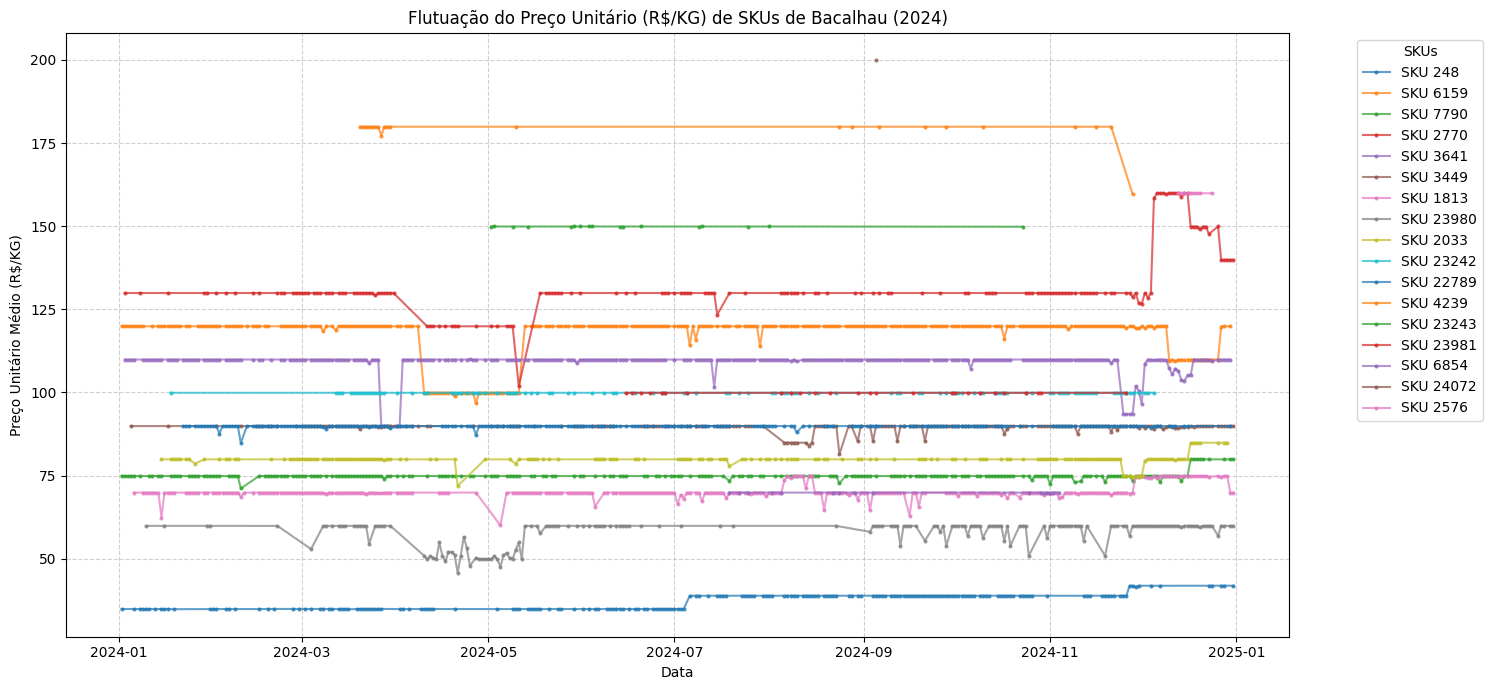

In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# --- Funções Auxiliares (copiadas do 02_feature_engineering.ipynb) ---
def clean_sku(sku_series):
    """Limpa a coluna SKU, removendo espaços e convertendo para inteiro."""
    return pd.to_numeric(sku_series.astype(str).str.strip(), errors='coerce').astype('Int64')

def load_csv(file_path):
    """Tenta carregar um CSV com encoding 'utf-8', e usa 'latin1' como fallback."""
    try:
        return pd.read_csv(file_path, encoding='utf-8')
    except UnicodeDecodeError:
        return pd.read_csv(file_path, encoding='latin1')
# --- Fim das Funções Auxiliares ---

print("Iniciando análise de preço unitário (R$/KG)...")

# --- 1. Definir Caminhos ---
RAW_DATA_PATH = os.path.join('..', 'data', 'raw')
VENDAS_FILE = os.path.join(RAW_DATA_PATH, 'vendas.csv')
PRODUTO_FILE = os.path.join(RAW_DATA_PATH, 'produto.csv')

# --- 2. Isolar SKUs de Bacalhau ---
df_prod = load_csv(PRODUTO_FILE)
df_prod['SKU'] = clean_sku(df_prod['SKU'])
df_prod['CATEGORIA'] = df_prod['CATEGORIA'].fillna('DESCONHECIDA')

# Pega a lista de SKUs da categoria
skus_bacalhau = df_prod[
    df_prod['CATEGORIA'] == 'Bacalhau & Pescados'
]['SKU'].unique()

print(f"Encontrados {len(skus_bacalhau)} SKUs na categoria 'Bacalhau & Pescados'.")

# --- 3. Carregar Vendas e Calcular Preço Unitário ---
df_vendas = load_csv(VENDAS_FILE)
df_vendas['SKU'] = clean_sku(df_vendas['SKU'])

# Filtra o dataframe de vendas APENAS para os SKUs de bacalhau
df_vendas_bacalhau = df_vendas[df_vendas['SKU'].isin(skus_bacalhau)].copy()

# Remove vendas com quantidade zero para evitar Divisão por Zero
df_vendas_bacalhau = df_vendas_bacalhau[df_vendas_bacalhau['QTD_VENDA'] > 0]

# Calcula o Preço Unitário (R$/KG) para CADA transação
df_vendas_bacalhau['PRECO_UNITARIO'] = df_vendas_bacalhau['FATUR_VENDA'] / df_vendas_bacalhau['QTD_VENDA']

# --- 4. Agregar Preço Diário por SKU ---
df_vendas_bacalhau['DATA_ATEND'] = pd.to_datetime(df_vendas_bacalhau['DATA_ATEND'])
df_daily_price = df_vendas_bacalhau.groupby(['DATA_ATEND', 'SKU'])['PRECO_UNITARIO'].mean().reset_index()

# --- 5. Imprimir Estatísticas de Volatilidade ---
print("\n--- Estatísticas de Preço Unitário (R$/KG) por SKU (2024) ---")
price_stats = df_daily_price.groupby('SKU')['PRECO_UNITARIO'].describe()
# Calcula o Coeficiente de Variação (Desvio Padrão / Média)
price_stats['CV (%)'] = (price_stats['std'] / price_stats['mean']) * 100
print(price_stats.to_string(float_format='%.2f'))

# --- 6. Plotar Gráfico (com Matplotlib) ---
print("\nGerando gráfico de flutuação de preço...")

plt.figure(figsize=(15, 7))

# Plota uma linha para cada SKU
for sku in df_daily_price['SKU'].unique():
    sku_data = df_daily_price[df_daily_price['SKU'] == sku]
    plt.plot(sku_data['DATA_ATEND'], sku_data['PRECO_UNITARIO'], label=f'SKU {sku}', marker='o', markersize=2, alpha=0.7)

plt.title('Flutuação do Preço Unitário (R$/KG) de SKUs de Bacalhau (2024)')
plt.xlabel('Data')
plt.ylabel('Preço Unitário Médio (R$/KG)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="SKUs")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Salva o gráfico como PNG
chart_path = 'preco_unitario_bacalhau.png'
plt.savefig(chart_path)

print(f"Gráfico da flutuação de preço salvo em: {chart_path}")